In [1]:
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.


In [24]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier


In [3]:
# Lodiang the dataset
df = pd.read_csv('data/creditcard.csv')

#checking the first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
# Counting how many normal (0) and fradulent (1) transactions we have
print(df['Class'].value_counts())

# Seeing this in percentage
print('\nPercentage')
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64

Percentage
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


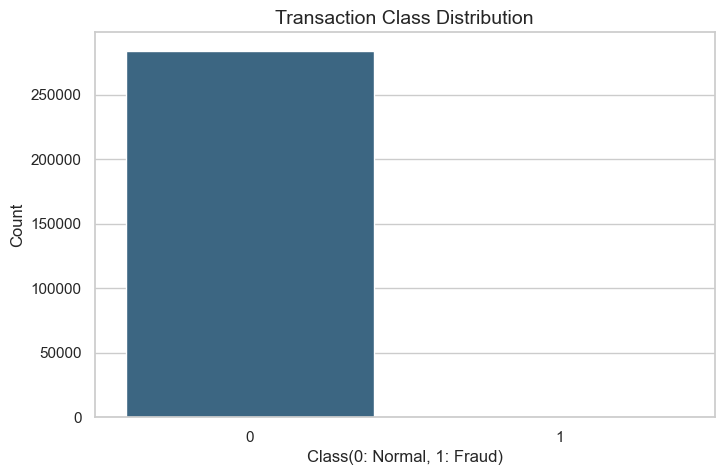

In [6]:
# Setting the Style
sns.set_theme(style="whitegrid")

#creating a countplot to visualize the imbalance
plt.figure(figsize=(8,5))
ax= sns.countplot(x='Class', data=df, hue='Class', palette='viridis', legend=False)

# Adding Titles
plt.title('Transaction Class Distribution', fontsize=14)
plt.xlabel('Class(0: Normal, 1: Fraud)', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.show()


In [7]:
# Comparing the 'Amount' for Normal vs Fraudulent transactions
print('--- Statistical Summary for Normal Transactions ---')
print(df[df['Class'] == 0]['Amount'].describe())

print('\n--- Statistical Summary for Fraudulent Transactions ---')
print(df[df['Class'] == 1] ['Amount'].describe())

--- Statistical Summary for Normal Transactions ---
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

--- Statistical Summary for Fraudulent Transactions ---
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


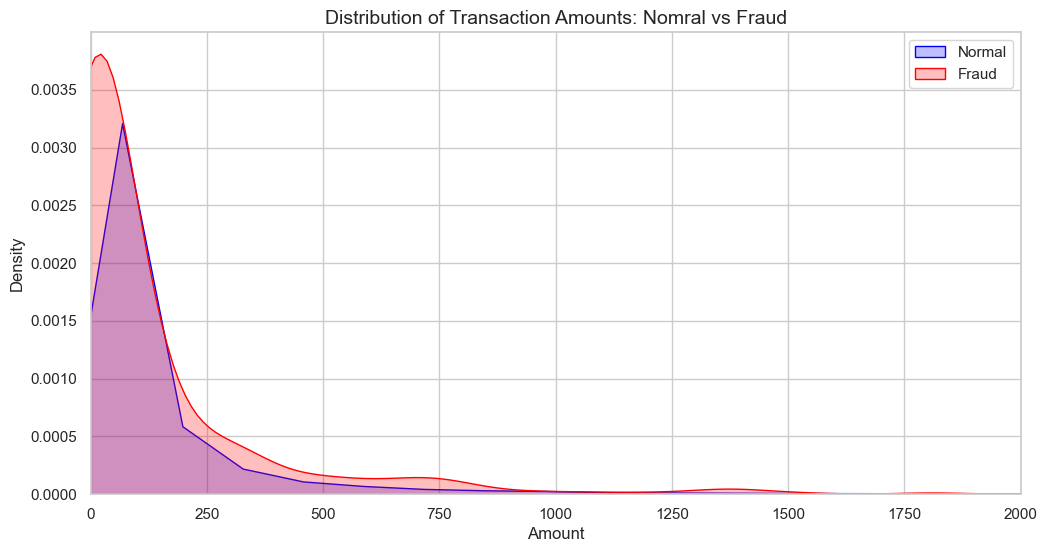

In [8]:
# Creating a plot to compare distributions of Amount for Fraud vs Normal 
plt.figure(figsize=(12, 6))

# Plot for Normal Transactions 
sns.kdeplot(df[df['Class'] == 0] ['Amount'], label='Normal', fill=True, color='blue')

# Plot for Fraudulent Transactions
sns.kdeplot(df[df['Class'] == 1] ['Amount'], label = 'Fraud', fill = True, color='red')

plt.title('Distribution of Transaction Amounts: Nomral vs Fraud', fontsize=14)
plt.xlabel('Amount', fontsize=12)
plt.xlim(0, 2000) #  Limiting to 200 for better visualization of the density
plt.legend()
plt.show()

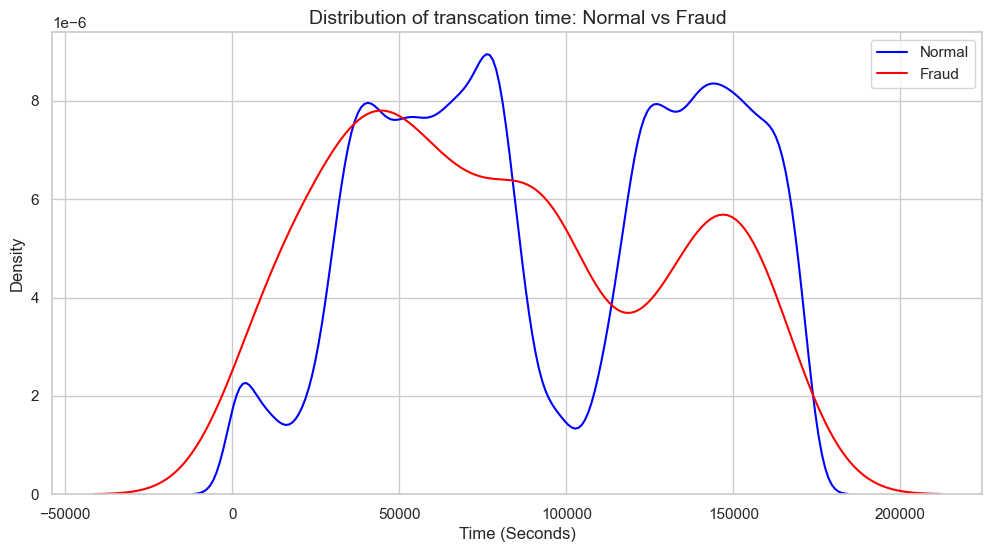

In [9]:
# Plotting Time distribution for Fraud vs Normal
plt.figure(figsize=(12, 6))

sns.kdeplot(df[df['Class'] == 0] ['Time'], label= 'Normal', color='blue')
sns.kdeplot(df[df['Class'] == 1] ['Time'], label='Fraud', color='red')

plt.title('Distribution of transcation time: Normal vs Fraud', fontsize=14)
plt.xlabel('Time (Seconds)', fontsize=12)
plt.legend()
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler, RobustScaler

#We will use RobustScaler for 'Amount' because it is better with outliers (very unusual values).
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Now we remove the original columns that are not scaled.
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Placing the new columns at the beginning of the dataframe for organization
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']

df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace = True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

df.head()




,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


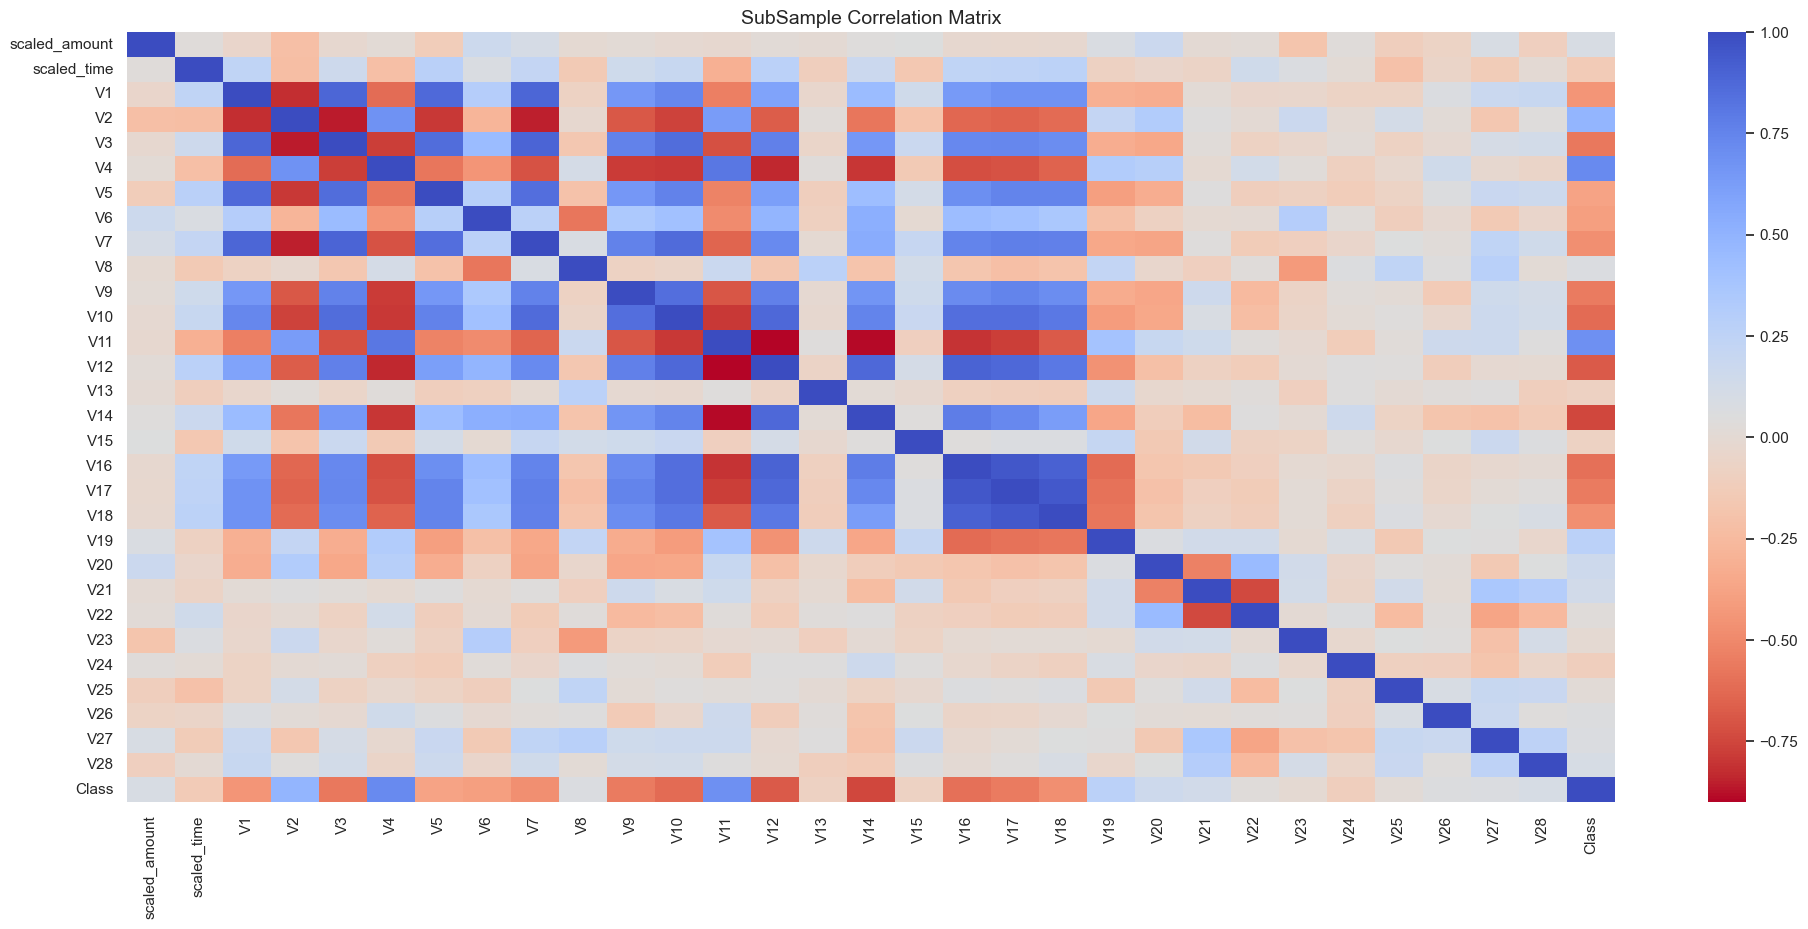

In [11]:
# 1. Creating the balanced sub-sample (Manual Under-sampling)
# Shuffle the data before organizing
df = df.sample(frac=1)

# Separating fraud from normal transactions (492 cases)
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:492]

# Concatenating both to create the new balanced dataframe
new_df = pd.concat([fraud_df, non_fraud_df])

# 2. Plotting the Correlation Matrix
f, ax = plt.subplots(figsize=(24,10))
corr = new_df.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot=False, annot_kws={'size':20}, ax=ax)
ax.set_title("SubSample Correlation Matrix", fontsize=14)
plt.show()

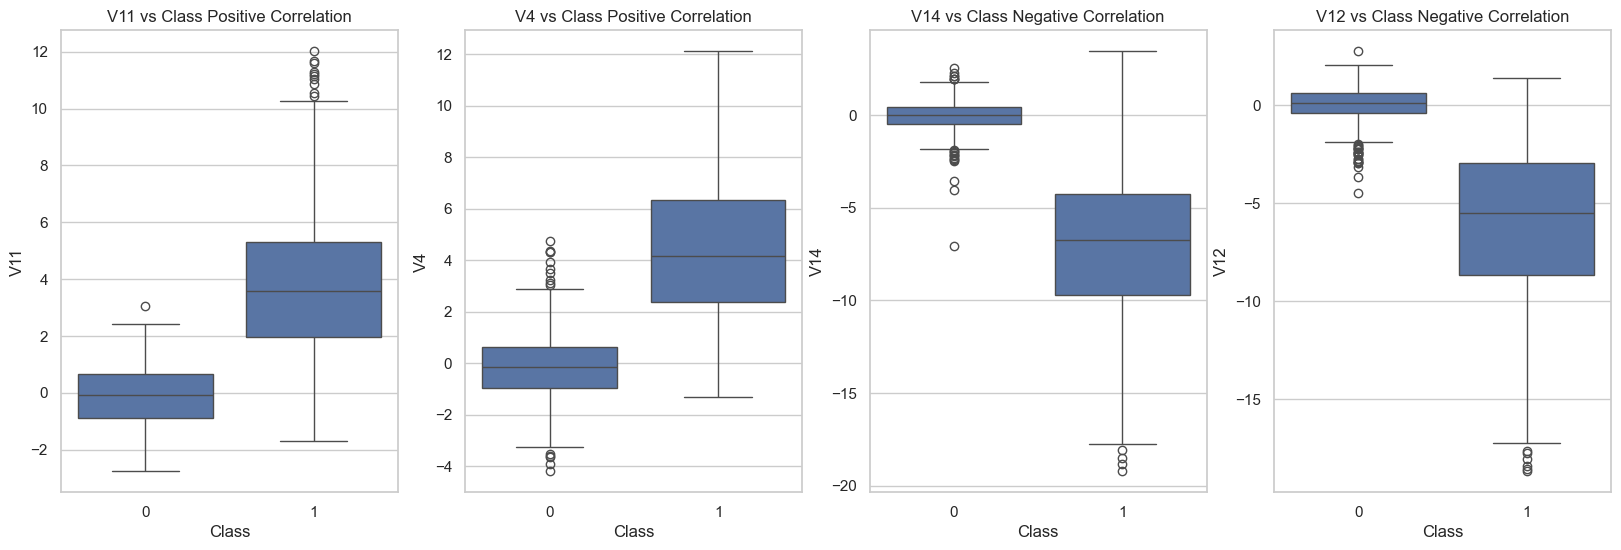

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting up the figure for multiple plots
# Using 4 columns now to include V12, which is also very relevant in your matrix
f, axes = plt.subplots(ncols=4, figsize=(20, 6))

# Boxplot for V11 (Positive correlation: higher values increase fraud probability)
sns.boxplot(x="Class", y="V11", data=new_df, ax=axes[0])
axes[0].set_title('V11 vs Class Positive Correlation')

# Boxplot for V4 (Positive correlation: higher values increase fraud probability)
sns.boxplot(x="Class", y="V4", data=new_df, ax=axes[1])
axes[1].set_title('V4 vs Class Positive Correlation')

# Boxplot for V14 (Negative correlation: lower values increase fraud probability)
sns.boxplot(x="Class", y="V14", data=new_df, ax=axes[2])
axes[2].set_title('V14 vs Class Negative Correlation')

# Boxplot for V12 (Adding V12 as it also showed strong negative correlation)
sns.boxplot(x="Class", y="V12", data=new_df, ax=axes[3])
axes[3].set_title('V12 vs Class Negative Correlation')

plt.show()

In [13]:
# --- Removing Outliers using IQR Method ---

# 1. V14 Outlier Removal (Negative Correlation)
v14_fraud = new_df['V14'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v14_fraud, 25), np.percentile(v14_fraud, 75)
v14_iqr = q75 - q25

v14_cut_off = v14_iqr * 1.5
v14_lower, v14_upper = q25 - v14_cut_off, q75 + v14_cut_off

# Identifying and dropping the outliers 
outliers = [x for x in v14_fraud if x < v14_lower or x > v14_upper]
new_df = new_df.drop(new_df[(new_df['V14'] > v14_upper) | (new_df['V14'] < v14_lower)].index)
print(f'V14 outliers: {len(outliers)}')

# 2. V11 Outlier Removal (Positive Correlation)
v11_fraud = new_df['V11'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v11_fraud, 25), np.percentile(v11_fraud, 75)
v11_iqr = q75 - q25

v11_cut_off = v11_iqr * 1.5
v11_lower, v11_upper = q25 - v11_cut_off, q75 + v11_cut_off

outliers = [x for x in v11_fraud if x < v11_lower or x > v11_upper]
new_df = new_df.drop(new_df[(new_df['V11'] >v11_upper) | (new_df['V11'] <v11_lower)].index)
print(f'V11 outliers: {len(outliers)}')


V14 outliers: 4
V11 outliers: 7


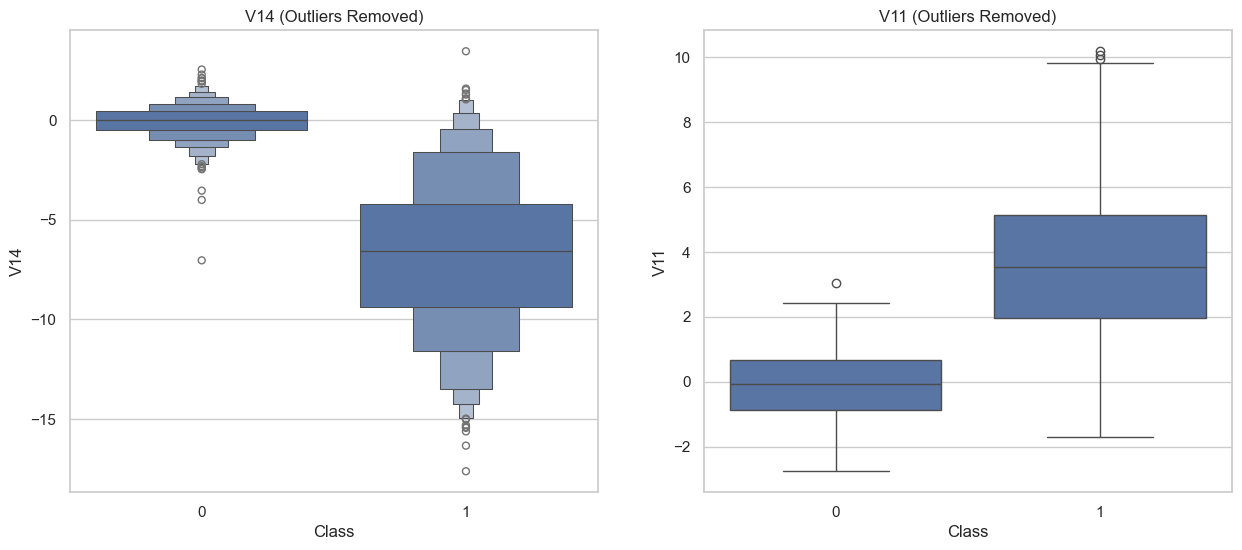

In [14]:
# Comparion: Boxplots after Outliers Removal
f, axes = plt.subplots(ncols =2, figsize=(15,6) )

# v14 afeter cleaning
sns.boxenplot(x="Class", y="V14", data=new_df, ax=axes[0])
axes[0].set_title('V14 (Outliers Removed)')

# V11 afeter cleaning
sns.boxplot(x='Class', y='V11', data=new_df, ax=axes[1])
axes[1].set_title('V11 (Outliers Removed)')

plt.show()

In [15]:
from sklearn.preprocessing import RobustScaler

# 1. Initialize the Scaler
# RobustScaler is less prone to outliers as it uses the median and IQR for scaling.
rob_scaler = RobustScaler()

# 2. Check if original columns exist before processing
# This ensures idempotency, preventing KeyErrors if the cell is executed multiple times.
if 'Amount' in df.columns and 'Time' in df.columns:
    # Creating scaled features
    df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
    df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

    # Safely dropping the original unscaled columns
    df.drop(['Time','Amount'], axis=1, inplace=True)
    print("Feature scaling completed successfully!")
else:
    print("Columns 'Amount' and 'Time' have already been processed or do not exist in the DataFrame.")

# 3. Display the first few rows of the transformed DataFrame
df.head()

Columns 'Amount' and 'Time' have already been processed or do not exist in the DataFrame.


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
121160,0.111786,-0.101023,-1.027439,0.297998,0.289979,-1.663528,-0.124847,-1.246738,0.386562,0.116348,...,-0.640860,-0.290243,-0.647985,-0.066423,-0.107939,-0.020509,0.913703,-0.248609,0.012764,0
85151,0.176064,-0.282675,1.323966,-1.417390,0.726485,-1.495615,-1.585699,0.430215,-1.598851,0.376183,...,-0.436166,0.041109,0.433091,0.048547,-0.327827,0.097025,-0.058543,0.065858,0.010625,0
52690,0.058129,-0.459357,1.370821,-0.461094,0.204226,-0.562617,-0.998089,-1.130347,-0.286239,-0.297873,...,-0.434278,-0.375573,-0.630785,0.027718,0.425851,0.272672,1.038142,-0.068503,0.008068,0
30279,-0.293440,-0.573773,-0.944767,0.546843,-0.392727,-1.566013,2.194779,3.409032,-0.427911,1.441646,...,0.056814,-0.031177,-0.118807,-0.187297,1.064720,0.072623,0.516767,0.204934,0.091227,0
210125,0.160693,0.624537,0.113218,-0.475699,0.816269,-2.864596,-0.191015,-0.450936,0.195700,-0.315713,...,-0.221294,-0.562469,-1.269691,0.273590,0.349081,-0.952463,-0.818094,-0.000877,-0.028995,0


In [18]:
# Separating the features (x) from the target (y)
X = new_df.drop('Class', axis= 1)
y = new_df['Class']

# Splitting the data: 80% for training and 20% for testing
# random_satae=42 ensures the split is the same every time you run iter

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split completed")
print(f"training set size: {len(X_train)} samnples")
print(f"Testing set size: {len(X_test)} samples")

Data split completed
training set size: 778 samnples
Testing set size: 195 samples


In [23]:
# 1. Initialize and train the model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# 2. Make predictions
y_pred_log = log_reg.predict(X_test)

# 3. Quick evaluation

print('---- Logistic Regression Results ----')
print(classification_report(y_test, y_pred_log))


---- Logistic Regression Results ----
              precision    recall  f1-score   support

           0       0.97      0.94      0.95        99
           1       0.94      0.97      0.95        96

    accuracy                           0.95       195
   macro avg       0.95      0.95      0.95       195
weighted avg       0.95      0.95      0.95       195



In [26]:
# 1. Initialize and train the model
# Using 100 estimators and random_state for reproducibility
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# 2. Make predicitons
y_pred_rf = rf_clf.predict(X_test)

# 3. Quick evaluation
print('---- Random Forest Results ----')
print(classification_report(y_test, y_pred_rf))

---- Random Forest Results ----
              precision    recall  f1-score   support

           0       0.93      0.94      0.93        99
           1       0.94      0.93      0.93        96

    accuracy                           0.93       195
   macro avg       0.93      0.93      0.93       195
weighted avg       0.93      0.93      0.93       195



## 🏆 Model Evaluation and Selection

After evaluating the models, **Logistic Regression** proved to be the superior choice for this fraud detection task.

### Why Logistic Regression?
While Random Forest is often more powerful for complex datasets, our preprocessing (RobustScaler and Outlier removal) made the data patterns clear enough for a linear model to excel.

### Final Comparison (Based on Confusion Matrix):
*   **Logistic Regression:** Identified **93 out of 96** frauds. Only **3** fraudulent transactions were missed (False Negatives).
*   **Random Forest:** Identified **89 out of 96** frauds. **7** fraudulent transactions were missed (False Negatives).

### Conclusion:
In fraud detection, **Recall** is the most critical metric. Missing a fraud (False Negative) results in direct financial loss. Since the **Logistic Regression** model had less than half the errors of the Random Forest, it will be our final production model.

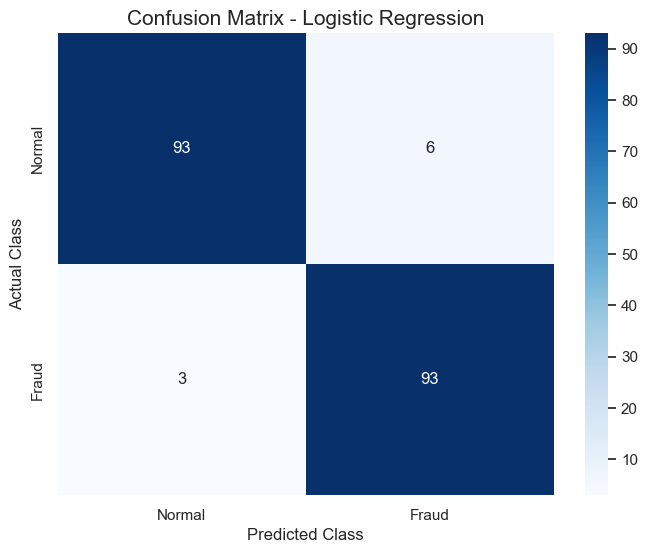

In [27]:
# 1. Generate the confusion matrix for Logistic Regression
# We use the predictions (y_pred_log) compared to the real values (y_test)
cm = confusion_matrix(y_test, y_pred_log)

# 2. Plotting using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Fraud'], 
            yticklabels=['Normal', 'Fraud'])

plt.title('Confusion Matrix - Logistic Regression', fontsize=15)
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.show()

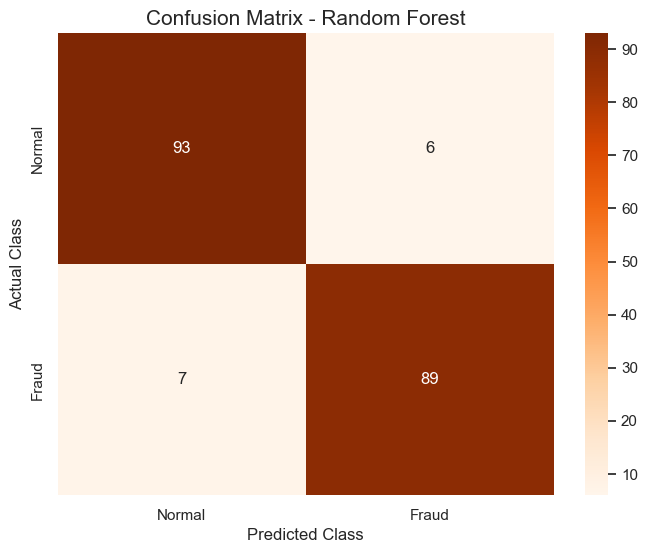

In [28]:
# 1. Generate the confusion matrix for Random Forest
# We use the predictions from the RF model (y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# 2. Plotting using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Normal', 'Fraud'], 
            yticklabels=['Normal', 'Fraud'])

plt.title('Confusion Matrix - Random Forest', fontsize=15)
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.show()